In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from models import PINN, device, dtype
from sklearn.model_selection import train_test_split

### Data Genration and Second Derivative Definition

In [2]:
def f(x):
    return 1/ (1 + 10 * x**2) * torch.sin(5 * x)  # define the function here

def target_physics(x):
        # First derivative
    f_prime = torch.autograd.grad(f(x).sum(), x, create_graph=True)[0]
    # print(f"f'(x)  = {f_prime.item()}")   # 3x² + 4x = 27 + 12 = 39
    # Second derivative
    f_double_prime = torch.autograd.grad(f_prime.sum(), x)[0]
    
    return f_double_prime

In [3]:
def generate_data(n_samples, a=-1, b=1):
    x = np.random.uniform(a, b, n_samples)  # Uniform in [-1, 1]
    # Target function
    y = f(torch.tensor(x, dtype=dtype, device=device).unsqueeze(1))  # Compute f(x) and convert to numpy
    return torch.tensor(x, dtype=dtype, device=device).unsqueeze(1), torch.tensor(y, dtype=dtype, device=device).unsqueeze(1)

# # Model the target physics
# def target_physics(x):
#     return -2 * torch.ones_like(x)

# Generate data with the function defined above
x_gen, y_gen = generate_data(10000, a=-2, b=0.2)
x_train, x_val, y_train, y_val = train_test_split(x_gen, y_gen, test_size=0.2, random_state=42)

C:\Users\gbell\AppData\Local\Temp\ipykernel_13780\154846920.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(x, dtype=dtype, device=device).unsqueeze(1), torch.tensor(y, dtype=dtype, device=device).unsqueeze(1)


In [4]:
model_1 = PINN([1, 64, 1]).to(device)
train_loss_1, val_loss_1 = model_1.train_model(
    x_train, y_train, 
    epochs=1000, 
    lr=1e-2,
    loss_tracking=True,                     # Enable loss tracking for visualization
    validation_data=(x_val, y_val),         # Provide validation data for tracking val loss 
    target_physics=target_physics,          # Definition of the second order derivative
    lambda_phy= 0.8,                        # Weight for the physics loss
    lambda_data= 0.2                        # Weight for the data loss
    )

Training Epoch: 100%|██████████| 1000/1000 [02:35<00:00,  6.41it/s]


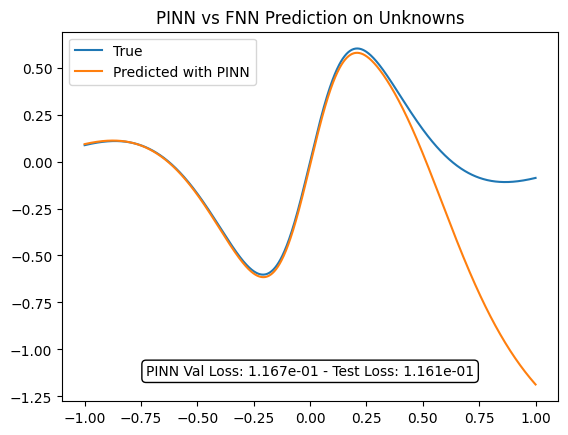

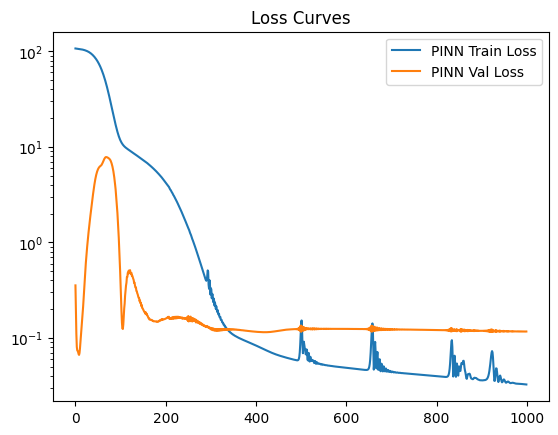

In [5]:

x_test = torch.linspace(-1, 1, 1000).unsqueeze(1).to(device)
y_true = f(x_test)

y_pred_1 = model_1.predict(x_test).cpu().numpy().flatten()
# y_pred_2 = model_2.predict(x_test).cpu().numpy().flatten()
test_loss_1 = np.mean((y_pred_1 - y_true.cpu().numpy().flatten()) ** 2)

x_test = x_test.cpu().numpy().flatten()
y_true = y_true.cpu().numpy().flatten()

plt.plot(x_test, y_true, label='True')
plt.plot(x_test, y_pred_1, label='Predicted with PINN')
# plt.plot(x_test, y_pred_2, label='Predicted with FNN')
plt.title('PINN vs FNN Prediction on Unknowns')
plt.legend()
textstr = f'PINN Val Loss: {val_loss_1[-1]:.3e} - Test Loss: {test_loss_1:.3e}'
props = dict(boxstyle='round', facecolor='white', edgecolor='black')
plt.text(0.5, 0.1, textstr, transform=plt.gca().transAxes, fontsize=10, verticalalignment='top', horizontalalignment='center', bbox=props)
plt.show()

plt.figure()
plt.semilogy(train_loss_1, label='PINN Train Loss')
plt.semilogy(val_loss_1, label='PINN Val Loss')
plt.title('Loss Curves')
plt.legend()
plt.show()

### perchè la validation loss è violentemente piu bassa della training?